In [119]:
using PlotlyJS
using Infiltrator
using XLSX
include("../model/pre_processing.jl")

# include("../../utils/main.jl")


generate_energy_reserves_cumulative (generic function with 1 method)

In [120]:
function load_deterministic_data(day, input_folder, ε=nothing, ρ=nothing)
    gen_df, loads_multi_df, gen_variable_multi_df, storage_df, random_loads_multi_df = generate_input_data(day, input_folder)
    # required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, reserve)
    file = joinpath(input_folder, G_UC_DATA, "Reserve.csv")
    if isfile(file)
        println("Reserve file found, loading reserves...")                            
        required_reserve = filter_day(day, CSV.read(file, DataFrame))
    else
        println("Reserve file not found, generating reserves...")
        required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
    random_loads_multi_df = filter_demand(loads_multi_df, random_loads_multi_df, required_reserve)
    return gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve
end

function load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    file = joinpath(input_folder, G_UC_DATA, "Energy reserve.csv")
    if isfile(file)
        println("Energy reserve file found, loading reserves...")
        return filter_day(day, CSV.read(file, DataFrame))
    else
        println("Energy reserve file not found, generating reserves...")
        return  generate_energy_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
end

load_energy_reserve (generic function with 1 method)

In [146]:
day = 7
input_folder = "../input/base_case_increased_storage_energy_v7.0.8.1"
ε = 0.025
ρ = 0.8
gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
;

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...


Checking that max_{i in T} ER[s,i,t]<=sum(R[S,τ], τ<=t) 

In [147]:
max_required_energy_reserve = combine(groupby(required_energy_reserve, [:t_hour]),[:reserve_up_MW, :reserve_down_MW].=> maximum, renamecols = false)
rename!(max_required_energy_reserve,:t_hour => :hour)
cumsum_required_reserve = combine(required_reserve, [:reserve_up_MW, :reserve_down_MW] .=> cumsum, renamecols = false)
# cumsum_required_reserve.hour .= required_reserve.hour
# cumsum_required_reserve = required_reserve[:, [:hour, :reserve_up_MW, :reserve_down_MW]] .|> cumsum 
delta_reserve = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- max_required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta_reserve.hour .= required_reserve.hour
all.(delta_reserve[:,[:reserve_up_MW, :reserve_down_MW]] .>=0)


Row,reserve_up_MW,reserve_down_MW
,Bool,Bool
1,true,true
2,true,true
3,true,true
4,true,true
5,true,true
6,true,true
7,true,true
8,true,true
9,true,true


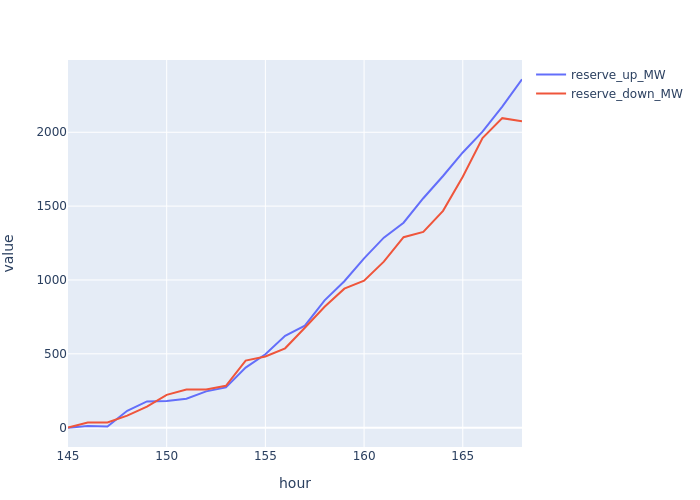

In [148]:
plot(stack(delta_reserve, [:reserve_up_MW, :reserve_down_MW]), x = :hour, y = :value, group = :variable)

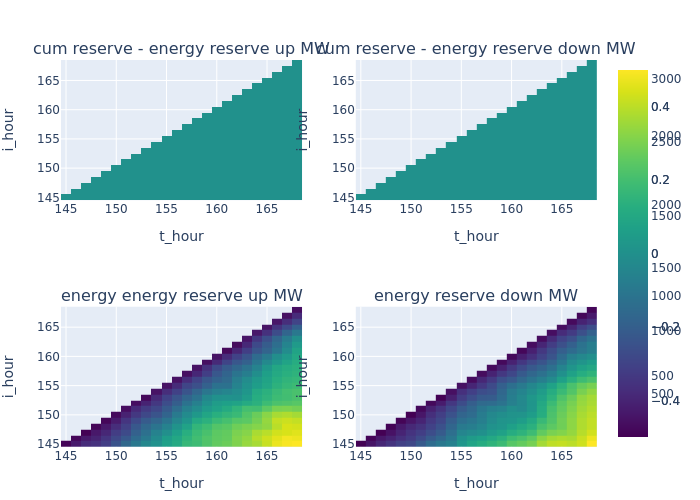

In [149]:
cumsum_required_reserve = required_energy_reserve[:,[:i_hour,:t_hour]] # cumualtive required reserve between i and t
f(i,t,df) = 
    (reserve_up_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_up_MW]),
    reserve_down_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_down_MW]),
    )
transform!(groupby(cumsum_required_reserve,[:i_hour, :t_hour]), [:i_hour, :t_hour] => ((i,t) -> f(i,t,required_reserve)) => AsTable)
;
# delta with energy reserve. 
delta = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta.i_hour .= cumsum_required_reserve.i_hour
delta.t_hour .= cumsum_required_reserve.t_hour
delta[delta.reserve_up_MW .>=0,:reserve_up_MW].= 0
delta[delta.reserve_down_MW .>=0,:reserve_down_MW].= 0
# delta = filter(row -> all(x -> x <= 0, row[[:reserve_up_MW, :reserve_down_MW]]), delta)
;
p1 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_up_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_down_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_up_MW, colorscale="Viridis"), Layout(title="energy energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_down_MW, colorscale="Viridis"), Layout(title="energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
# p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"))
# p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"))
[p1 p2; p3 p4]

In [125]:
include("../model/utils/empirical_mu.jl")
model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve)
;


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0xf04a6924
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 5e+03]
Presolve removed 1912 rows and 2028 columns
Presolve time: 0.01s
Pr

In [134]:
println(value(model[:epsilon_variance]))
println(value(model[:theta]))
println(value(model[:reserve]))
# println(value(model[:slack]))
println(objective_value(model))

2.220003080300768e-6
2733.289865403315
9944.843535950002
-7211.553668326688


In [135]:
# function calculate_mu()
#     mu = []
#     for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
#         aux = collect(skipmissing(sol_1[:, θ] ./ sol_1[:, RES]))
#         push!(mu, mean(values(aux)))
#     end
#     mu_df = DataFrame(mu = mu, variable = ["θUPDIS/RESUPDIS", "θUPCH/RESUPCH", "θDNDIS/RESDNDCH", "θDNCH/RESDNCH"])
#     return unstack(mu_df, :variable, :mu)
# end

function calculate_mu_t(sol_1)
    mu = DataFrame()
    for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
        mu[!, Symbol("$θ/$RES")] = sol_1[:, θ] ./ sol_1[:, RES]
    end
    mu[!, :t] = sol_1.t
    mu = mu[1:end-1, :]
    return unstack(stack(mu, Not(:t)),:t, :value)
end
mu_t = calculate_mu_t(sol_1)



Row,variable,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,θUPDIS/RESUPDIS,1.0,0.943117,0.929361,0.871713,0.867083,0.826917,0.792291,0.604885,0.34304,0.175317,0.0951427,0.0687948,0.0504315,0.0400752,0.0317688,0.0227609,1.30005e-12,1.02004e-12,1.06999e-12,1.1981e-12,1.3889e-12,1.10948e-12,1.39984e-12,1.87795e-12
2,θUPCH/RESUPCH,1.0,0.944255,0.926195,0.867326,0.872556,0.823375,0.777708,0.58675,0.32598,0.164672,0.0864262,0.0656778,0.0577329,0.0389608,0.0307215,0.0219242,1.21536e-12,1.02596e-12,9.89717e-13,1.14365e-12,1.27027e-12,1.06971e-12,1.24436e-12,1.44445e-12
3,θDNDIS/RESDNDIS,1.0,0.930241,0.852692,0.845597,0.821023,0.719974,0.64116,0.472069,0.235728,0.114949,0.0800373,0.0557781,0.0536939,0.036195,0.0276934,0.026624,0.0192852,0.0173257,0.018376,0.0117859,0.0104527,9.41486e-13,8.70779e-13,9.71746e-13
4,θDNCH/RESDNCH,1.0,0.935293,0.851931,0.859988,0.822916,0.726154,0.64774,0.486421,0.253652,0.121996,0.0870096,0.0572526,0.0517399,0.0365279,0.028286,0.0284983,0.0193255,0.0180194,0.0191932,0.0123626,0.0111533,9.85737e-13,9.44134e-13,1.23746e-12


┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


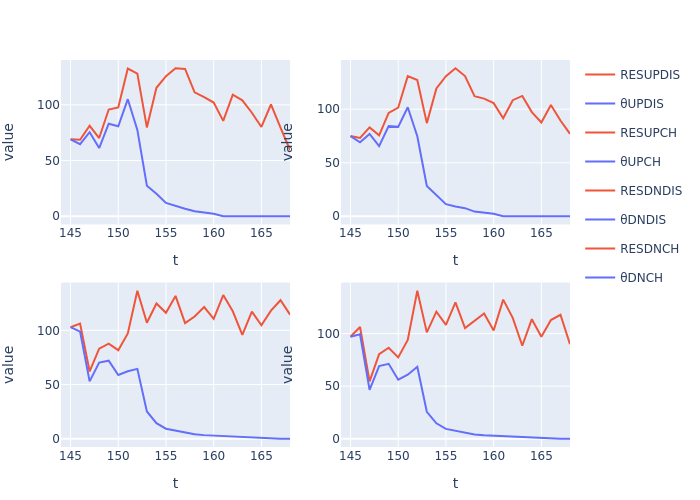

In [136]:
ks = [:θUPDIS,:RESUPDIS]
p1 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θUPCH,:RESUPCH]
p2 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNDIS,:RESDNDIS]
p3 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNCH,:RESDNCH]
p4 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

[p1 p2; p3 p4]

In [137]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sUPDIS, colorscale="Viridis"), Layout(title="sUPDIS", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sUPCH, colorscale="Viridis"), Layout(title="sUPCH", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"), Layout(title="sDNDIS", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"), Layout(title="sDNCH", xaxis_title="t_hour", yaxis_title="i_hour"))
[p1 p2; p3 p4]

ArgumentError: ArgumentError: column name :sUPDIS not found in the data frame

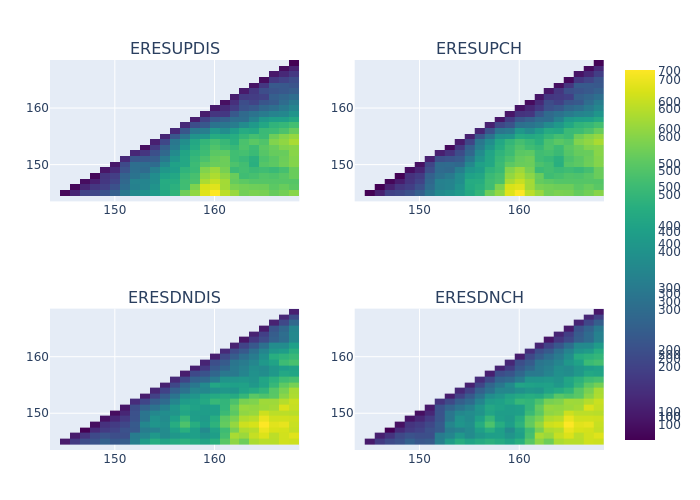

In [138]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPDIS, colorscale="Viridis"), Layout(title="ERESUPDIS"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPCH, colorscale="Viridis"), Layout(title="ERESUPCH"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNDIS, colorscale="Viridis"), Layout(title="ERESDNDIS"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNCH, colorscale="Viridis"), Layout(title="ERESDNCH"))
[p1 p2; p3 p4]

In [143]:
rhos = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
day = 7

ε = 0.025
ρ = 0.8

mu_t_all = DataFrame()
for rho in rhos
    input_folder = "../input/base_case_increased_storage_energy_v7.$(rho).1"
    gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
    required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve)
    mu_t = calculate_mu_t(sol_1)
    mu_t = insertcols(mu_t, 1, :rho => rho)
    append!(mu_t_all, mu_t)
end

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0x587fdeac
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range   

In [144]:
mu_t_all

Row,rho,variable,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,Float64,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,0.0,θUPDIS/RESUPDIS,1.0,0.920162,0.856364,0.854064,0.845919,0.7482,0.678193,0.458371,0.23283,0.0721868,0.0930423,0.070145,0.059713,0.0559605,0.0328919,0.024899,0.0221957,0.0200919,0.0181845,0.0149908,0.0118454,0.00950137,0.0124611,0.0102
2,0.0,θUPCH/RESUPCH,1.0,0.912584,0.851045,0.837729,0.836717,0.749371,0.65675,0.436321,0.207067,0.0875994,0.0815705,0.0655621,0.0694518,0.0577049,0.0310713,0.0240559,0.0213997,0.021749,0.014796,0.0141394,0.0113876,0.0094761,0.0108887,0.00800974
3,0.0,θDNDIS/RESDNDIS,1.0,0.925049,0.897145,0.854152,0.82286,0.820688,0.749864,0.688691,0.471505,0.214274,0.176362,0.0804768,0.0954072,0.0833036,0.0440515,0.037868,0.0286913,0.0313783,0.0237439,0.0203557,0.0130315,0.0128905,0.0104438,0.00923789
4,0.0,θDNCH/RESDNCH,1.0,0.929157,0.906208,0.87474,0.823052,0.829597,0.749317,0.690329,0.490526,0.233579,0.192734,0.0832315,0.081855,0.0731131,0.0461258,0.0408876,0.0304165,0.0266468,0.027008,0.0225285,0.0131806,0.0138054,0.0114098,0.0122492
5,0.1,θUPDIS/RESUPDIS,1.0,0.912982,0.883946,0.886701,0.833919,0.784988,0.691604,0.506534,0.245469,0.12998,0.106126,0.0657892,0.0486876,0.0410218,0.0296075,0.025658,0.0243333,0.0164651,0.0144703,0.0129795,0.00903412,0.00910723,0.0090042,0.00860212
6,0.1,θUPCH/RESUPCH,1.0,0.913321,0.882709,0.877052,0.840895,0.78609,0.681326,0.479355,0.229339,0.123988,0.0944968,0.061069,0.0479635,0.0420823,0.0280492,0.0246908,0.0227276,0.0171315,0.0140562,0.0118689,0.00874724,0.00849719,0.00798106,0.00674445
7,0.1,θDNDIS/RESDNDIS,1.0,0.897614,0.869255,0.818305,0.795061,0.712644,0.495609,0.284115,0.140929,0.0953919,0.0748701,0.042077,0.0431178,0.033917,0.0287555,0.018022,0.0167046,0.020811,0.0112695,0.011934,0.0104208,0.00750963,0.00914992,0.00566478
8,0.1,θDNCH/RESDNCH,1.0,0.900311,0.879244,0.833037,0.80426,0.734126,0.525288,0.303532,0.14622,0.102281,0.0788363,0.045683,0.0424781,0.0318205,0.0308575,0.0183429,0.017118,0.0195864,0.0137551,0.012682,0.0111567,0.00785281,0.0106441,0.00701193
9,0.2,θUPDIS/RESUPDIS,1.0,0.915198,0.885266,0.843353,0.839732,0.826321,0.738533,0.591249,0.363669,0.194874,0.130671,0.0666538,0.0584708,0.0382546,0.0361177,0.038693,0.0228167,0.0190391,0.0240501,0.0137049,0.00969976,0.00694498,0.00691438,0.00744823


In [145]:
# using CSV
# CSV.write("mu_t_all.csv", mu_t_all) 